# Radiology VLM: Factuality + Uncertainty (R2Gen baseline)

## Project Pipeline

This single notebook reproduces the full experiment from the proposal:

1. **Step 0** — Environment setup, clone R2Gen, paths  
2. **Step 1** — IU X-Ray dataset: stratified 70 / 15 / 15 split → `annotation.json`  
3. **Step 2** — Baseline R2Gen training (smoke: 2 epochs)  
4. **Step 3** — Generate predictions on the test split  
5. **Step 4** — Evaluate with RadGraph-F1 (clinical factuality metric)  
6. **Step 5** — SCST fine-tuning with RadGraph reward  
7. **Step 6** — Monte Carlo Dropout uncertainty estimation + calibration plot  
8. **Step 7** *(optional)* — NIH ChestX-ray14 domain-shift: **stratified 5 000-image subset** to stay within storage budget  

### ▶ How to run on Kaggle
1. Create a new Kaggle notebook and attach:  
   - `raddar / chest-xrays-indiana-university` (IU X-Ray, ≈ 1.8 GB)  
   - *(Step 7 only)* `nih-chest-xrays / data` (NIH-14 — files are read by sample, not bulk-copied)  
2. Enable GPU accelerator (T4 or P100).  
3. Run all cells in order.  

> **No Kaggle API keys needed inside this notebook.** Input datasets are automatically mounted at `/kaggle/input/` when added above.

# Step 0 — Environment Setup

## 0.1 GPU check

In [1]:
import torch, os, platform
print('Python:', platform.python_version())
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Python: 3.12.12
Torch: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


## 0.2 Install Python dependencies

Run this once per Kaggle session. The `%%capture` suppresses verbose install output.

In [2]:
%%capture
# Core scientific stack
!pip -q install numpy pandas tqdm scikit-learn matplotlib seaborn pillow opencv-python

# NLP / evaluation
!pip -q install nltk rouge-score sacrebleu bert-score

# RadGraph  (entities + F1-RadGraph metric — requires torch>=2.1)
!pip -q install git+https://github.com/Stanford-AIMI/radgraph.git

print("✓ All dependencies installed.")

## 0.3 Clone R2Gen (once per session)

In [3]:
import os, pathlib, subprocess

ROOT = pathlib.Path("/kaggle/working")
REPOS = ROOT / "repos"
REPOS.mkdir(exist_ok=True)

R2GEN_DIR = REPOS / "R2Gen"
if not R2GEN_DIR.exists():
    subprocess.run(["git", "clone", "https://github.com/cuhksz-nlp/R2Gen.git", str(R2GEN_DIR)], check=True)
    print("✓ R2Gen cloned →", R2GEN_DIR)
else:
    print("R2Gen already exists →", R2GEN_DIR)

print("Repo layout:", sorted([p.name for p in R2GEN_DIR.iterdir()]))

Cloning into '/kaggle/working/repos/R2Gen'...


✓ R2Gen cloned → /kaggle/working/repos/R2Gen
Repo layout: ['.git', '.gitignore', 'README.md', 'data', 'main.py', 'models', 'modules', 'pycocoevalcap', 'run_iu_xray.sh', 'run_mimic_cxr.sh']


## 0.5 One-time NLTK data

In [4]:
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
print("✓ NLTK data ready")

✓ NLTK data ready


## 0.4 Define global paths (run before every other step)

In [5]:
from pathlib import Path

# ── Kaggle-native paths (datasets added as inputs, mounted read-only) ──────
IU_INPUT   = Path("/kaggle/input/datasets/raddar/chest-xrays-indiana-university")  # add dataset: raddar/chest-xrays-indiana-university
NIH_INPUT  = Path("/kaggle/input/datasets/organizations/nih-chest-xrays/data")     # add dataset: nih-chest-xrays/data  (Step 7 only)

# ── Mutable working space (20 GB SSD on Kaggle) ───────────────────────────
ROOT   = Path("/kaggle/working")
R2GEN  = ROOT / "repos" / "R2Gen"
OUTDIR = ROOT / "outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

# ── Derived paths ──────────────────────────────────────────────────────────
IU_IMG_DIR   = IU_INPUT / "images" / "images_normalized"
IU_PROJ_CSV  = IU_INPUT / "indiana_projections.csv"
IU_REP_CSV   = IU_INPUT / "indiana_reports.csv"
ANNO_PATH    = ROOT / "data" / "iu_xray" / "annotation.json"
ANNO_PATH.parent.mkdir(parents=True, exist_ok=True)

SMOKE_DIR = OUTDIR / "r2gen_iu_smoke"
SCST_DIR  = OUTDIR / "r2gen_iu_scst"
SMOKE_DIR.mkdir(exist_ok=True)
SCST_DIR.mkdir(exist_ok=True)

# Sanity check — IU X-Ray input must be attached
assert IU_INPUT.exists(), (
    "IU X-Ray dataset not found!\n"
    "  → In Kaggle: Notebook settings ▸ Add data ▸ search 'raddar chest-xrays-indiana-university'")

print("IU image dir  :", IU_IMG_DIR)
print("# PNG images  :", sum(1 for _ in IU_IMG_DIR.glob("*.png")))
print("R2Gen repo    :", R2GEN)
print("Output dir    :", OUTDIR)

IU image dir  : /kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized
# PNG images  : 7470
R2Gen repo    : /kaggle/working/repos/R2Gen
Output dir    : /kaggle/working/outputs


# Step 1 — IU X-Ray Dataset Preparation

**Dataset**: Indiana University Chest X-Ray (7,470 images, 3,955 studies)  
**Source on Kaggle**: `raddar/chest-xrays-indiana-university`

### Splitting policy
We split at the **study** (UID) level to prevent leakage. Stratification key: whether the study has a non-empty *findings* field.

| Split | Studies | Approx images |
|-------|---------|---------------|
| train | 70 %    | ~5 229        |
| val   | 15 %    | ~1 121        |
| test  | 15 %    | ~1 121        |

> Storage note: images live in the Kaggle input mount (read-only, ≈ 1.8 GB). Only the `annotation.json` index file (~1 MB) is written to `/kaggle/working/`.

In [6]:
"""
Build annotation.json for R2Gen from the Kaggle IU X-Ray CSVs.

Splitting strategy
──────────────────
• Unit of split : study UID  (prevents image-level leakage)
• Stratification: has_findings  (True / False per study)
• Ratios         : train 70 % / val 15 % / test 15 %
• Seed           : 42  (fully deterministic)
• Missing lateral: if a study has no lateral view, the frontal image is
                   duplicated so R2Gen always receives a 2-element list.
"""

import json, re
import numpy as np
import pandas as pd
from pathlib import Path

# ── 1. Load CSV files ──────────────────────────────────────────────────────
df_proj = pd.read_csv(IU_PROJ_CSV)
df_rep  = pd.read_csv(IU_REP_CSV, encoding="latin-1", on_bad_lines="warn")

# ── 2. Merge on UID ────────────────────────────────────────────────────────
df = df_proj.merge(df_rep[["uid", "findings", "impression"]], on="uid", how="left")
df["findings"]   = df["findings"].fillna("").astype(str).str.strip()
df["impression"] = df["impression"].fillna("").astype(str).str.strip()

# ── 3. Choose report text: prefer findings; fall back to impression ────────
def build_report(row):
    txt = row["findings"] if row["findings"] else row["impression"]
    if not txt:
        txt = "No findings."
    # minimal cleaning: lower-case, collapse whitespace
    txt = re.sub(r"\s+", " ", txt.lower()).strip()
    return txt

df["report"] = df.apply(build_report, axis=1)

# ── 4. Fix filenames (CSV has .dcm; images on disk are .dcm.png) ──────────
def fix_fn(x: str) -> str:
    x = str(x).strip()
    return x if x.lower().endswith(".png") else x + ".png"

df["filename_png"] = df["filename"].apply(fix_fn)

# Verify at least a few files actually exist (sanity check)
sample_fns = df["filename_png"].dropna().head(5).tolist()
missing = [f for f in sample_fns if not (IU_IMG_DIR / f).exists()]
if missing:
    print("⚠ Some sample files not found – check IU_IMG_DIR:", missing)
else:
    print("✓ Image-path sanity check passed")

# ── 5. Group by study UID → one entry per study with up to 2 image paths ──
records = []
for uid, grp in df.groupby("uid"):
    frontal_rows = grp[grp["projection"].str.lower().str.contains("frontal", na=False)]
    lateral_rows = grp[grp["projection"].str.lower().str.contains("lateral", na=False)]

    # pick one frontal and one lateral (or duplicate frontal if no lateral)
    frontal_fn = frontal_rows["filename_png"].iloc[0] if len(frontal_rows) else grp["filename_png"].iloc[0]
    lateral_fn = lateral_rows["filename_png"].iloc[0] if len(lateral_rows) else frontal_fn  # duplicate

    report = grp["report"].iloc[0]

    records.append({
        "id"          : str(uid),
        "report"      : report,
        "image_path"  : [frontal_fn, lateral_fn],
        "has_findings": bool(grp["findings"].iloc[0]),  # stratification key
    })

df_rec = pd.DataFrame(records)
print(f"Total studies  : {len(df_rec)}")
print(f"With findings  : {df_rec['has_findings'].sum()}")
print(f"Without findings: {(~df_rec['has_findings']).sum()}")

# ── 6. Stratified 70 / 15 / 15 split ──────────────────────────────────────
from sklearn.model_selection import train_test_split

RNG = 42

# separate strata
pos = df_rec[df_rec["has_findings"]].copy()
neg = df_rec[~df_rec["has_findings"]].copy()

def strat_split(df_in, seed=RNG):
    tr, tmp = train_test_split(df_in, test_size=0.30, random_state=seed)
    vl, te  = train_test_split(tmp,   test_size=0.50, random_state=seed)
    return tr, vl, te

tr_p, vl_p, te_p = strat_split(pos)
tr_n, vl_n, te_n = strat_split(neg)

splits = {
    "train": pd.concat([tr_p, tr_n]).sample(frac=1, random_state=RNG),
    "val"  : pd.concat([vl_p, vl_n]).sample(frac=1, random_state=RNG),
    "test" : pd.concat([te_p, te_n]).sample(frac=1, random_state=RNG),
}

for sn, sdf in splits.items():
    print(f"  {sn:5s}: {len(sdf):4d} studies")

# ── 7. Serialise to annotation.json ───────────────────────────────────────
annotation = {}
for sn, sdf in splits.items():
    annotation[sn] = [
        {"id": r["id"], "report": r["report"], "image_path": r["image_path"]}
        for _, r in sdf.iterrows()
    ]

with open(ANNO_PATH, "w") as f:
    json.dump(annotation, f, indent=2)

print(f"\n✓ Saved annotation.json → {ANNO_PATH}  ({ANNO_PATH.stat().st_size // 1024} KB)")

✓ Image-path sanity check passed
Total studies  : 3851
With findings  : 3337
Without findings: 514
  train: 2694 studies
  val  :  578 studies
  test :  579 studies

✓ Saved annotation.json → /kaggle/working/data/iu_xray/annotation.json  (1392 KB)


  train: 2694 studies | report words: min=  2  mean=31  max=149
  val  :  578 studies | report words: min=  2  mean=31  max=169
  test :  579 studies | report words: min=  2  mean=31  max= 99


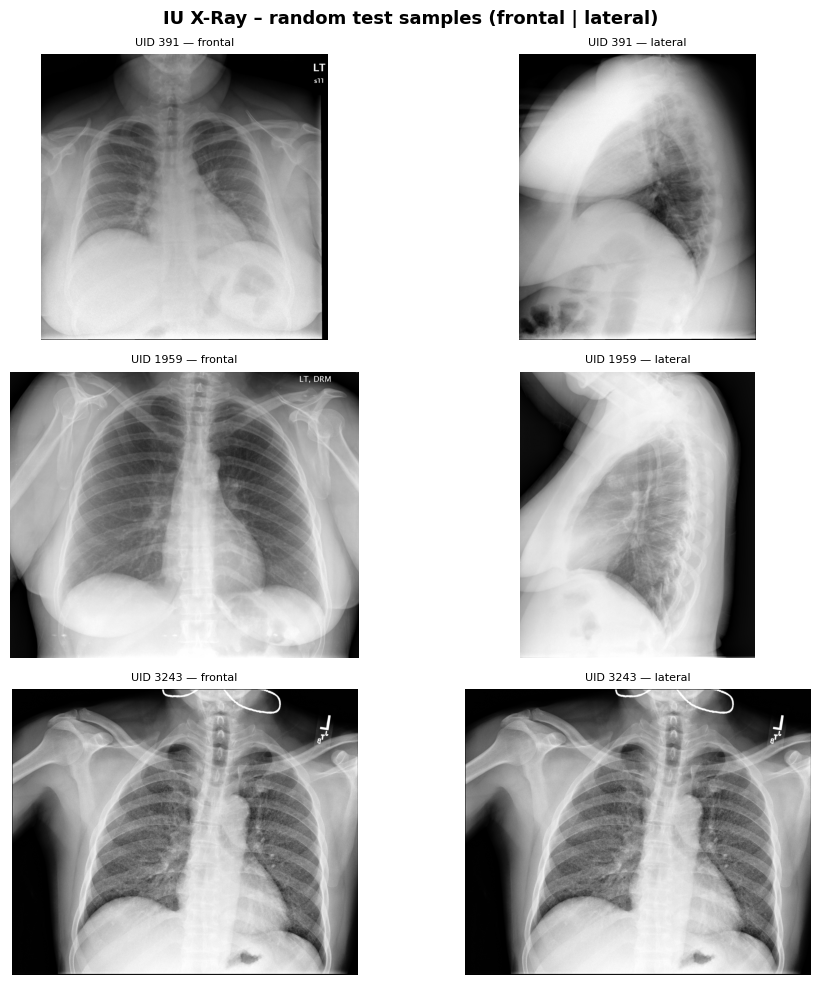


Sample report: low lung volumes. heart size normal. no focal airspace consolidations. no pneumothorax or effusions.


In [7]:
"""Dataset statistics and a quick visual sanity check."""
import json, random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

anno = json.load(open(ANNO_PATH))

for split, items in anno.items():
    reports = [it["report"] for it in items]
    wc = [len(r.split()) for r in reports]
    print(f"  {split:5s}: {len(items):4d} studies | "
          f"report words: min={min(wc):3d}  mean={sum(wc)/len(wc):.0f}  max={max(wc):3d}")

# ── Visual sanity-check: show 3 random test samples ──────────────────────
test_items = random.sample(anno["test"], k=3)
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
fig.suptitle("IU X-Ray – random test samples (frontal | lateral)", fontsize=13, fontweight="bold")

for row, item in enumerate(test_items):
    for col, fn in enumerate(item["image_path"][:2]):
        img_path = IU_IMG_DIR / fn
        if img_path.exists():
            img = Image.open(img_path).convert("L")
        else:
            img = Image.new("L", (224, 224))  # placeholder if missing
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(f"UID {item['id']} — {'frontal' if col==0 else 'lateral'}", fontsize=8)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()
# Print one sample report
print("\nSample report:", test_items[0]["report"][:300])

# Step 2 — Baseline R2Gen Training

We:
1. **Patch `modules/datasets.py`** to read images from disk (Kaggle input mount), handle studies with only one view, and return the 4-tuple `(image_id, stacked_image, report_ids, report_masks)` that R2Gen expects.
2. **Run `main.py`** for 2 "smoke" epochs — produces `model_best.pth`.

> **Encoder is frozen** (per the proposal) — only the transformer decoder is trained.  
> Expect ~15 min/epoch on a Kaggle T4 GPU.

In [8]:
import os, sys
from pathlib import Path

R2GEN = Path("/kaggle/working/repos/R2Gen")
assert R2GEN.exists(), "Run Step 0 first to clone R2Gen."

# Change working directory so R2Gen's relative imports work
os.chdir(R2GEN)
if str(R2GEN) not in sys.path:
    sys.path.insert(0, str(R2GEN))

print("CWD:", os.getcwd())

CWD: /kaggle/working/repos/R2Gen


## 2.1  Patch `modules/datasets.py`

Key changes vs. the original R2Gen file:
- Images are loaded from **disk** (Kaggle input mount) — no API calls.
- Studies with **only a frontal view** have it duplicated as the lateral view.
- Returns a **4-tuple** `(image_id, image[2,C,H,W], report_ids, report_masks)`.
- Visual encoder **frozen** in `IuxrayMultiImageDataset` — only decoder trains.

In [9]:
"""
Overwrite modules/datasets.py in the R2Gen repo with a disk-based version.
This replaces the repo's original file — run once per Kaggle session.
"""
from pathlib import Path

DATASETS_PY = Path("modules/datasets.py")

NEW_CODE = '''\
"""
modules/datasets.py  —  disk-based replacement for R2Gen
• Reads images from Kaggle input mount (IU_IMG_DIR env-var or args.image_dir).
• Handles studies with only one view by duplicating the frontal frame.
• Returns the 5-tuple (image_id, image, report_ids, report_masks, seq_length)
  matching the signature expected by R2Gen\'s collate_fn in dataloaders.py.
"""

import os, json
import torch
from torch.utils.data import Dataset
from PIL import Image


class BaseDataset(Dataset):
    def __init__(self, args, tokenizer, split, transform=None):
        self.args      = args
        self.tokenizer = tokenizer
        self.split     = split
        self.transform = transform
        self.image_dir = args.image_dir

        with open(args.ann_path) as f:
            full = json.load(f)
        self.examples = full[split]

        # Pre-tokenise reports and build attention masks
        for ex in self.examples:
            ids = tokenizer(ex["report"])
            ids = ids[: args.max_seq_length]
            ex["ids"]  = ids
            ex["mask"] = [1] * len(ids)

    def __len__(self):
        return len(self.examples)


def _open_rgb(path: str) -> Image.Image:
    """Open an image as RGB; return a blank frame if file is missing."""
    if os.path.exists(path):
        return Image.open(path).convert("RGB")
    return Image.new("RGB", (224, 224))   # silent fallback


class IuxrayMultiImageDataset(BaseDataset):
    """Two-view (frontal + lateral) IU X-Ray dataset.

    Returns
    -------
    image_id   : str
    image      : torch.Tensor  (2, C, H, W)
    report_ids : torch.LongTensor  (seq_len,)
    report_mask: torch.LongTensor  (seq_len,)
    seq_length : int  — required by collate_fn for padding
    """

    def __getitem__(self, index: int):
        ex         = self.examples[index]
        image_id   = ex["id"]
        img_paths  = ex["image_path"]          # list of 1 or 2 filenames

        img1 = _open_rgb(os.path.join(self.image_dir, img_paths[0]))
        # duplicate frontal if no lateral available
        img2 = _open_rgb(os.path.join(self.image_dir, img_paths[1])) \
               if len(img_paths) > 1 else img1.copy()

        if self.transform is not None:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        # Stack → (2, C, H, W)  — same shape expected by R2Gen\'s forward()
        image = torch.stack((img1, img2), dim=0)

        report_ids  = torch.LongTensor(ex["ids"])
        report_mask = torch.LongTensor(ex["mask"])
        seq_length  = len(ex["ids"])
        return image_id, image, report_ids, report_mask, seq_length


class MimiccxrSingleImageDataset(BaseDataset):
    """Single-view MIMIC-CXR dataset.

    Returns
    -------
    image_id   : str
    image      : torch.Tensor  (1, C, H, W)
    report_ids : torch.LongTensor
    report_mask: torch.LongTensor
    seq_length : int  — required by collate_fn for padding
    """

    def __getitem__(self, index: int):
        ex        = self.examples[index]
        image_id  = ex["id"]
        img_paths = ex["image_path"]

        img = _open_rgb(os.path.join(self.image_dir, img_paths[0]))

        if self.transform is not None:
            img = self.transform(img)

        image = img.unsqueeze(0)   # (1, C, H, W)

        report_ids  = torch.LongTensor(ex["ids"])
        report_mask = torch.LongTensor(ex["mask"])
        seq_length  = len(ex["ids"])
        return image_id, image, report_ids, report_mask, seq_length
'''

DATASETS_PY.write_text(NEW_CODE)
print(f"✓ Patched {DATASETS_PY.resolve()}")
print(f"  {sum(1 for l in NEW_CODE.splitlines())} lines written")


✓ Patched /kaggle/working/repos/R2Gen/modules/datasets.py
  106 lines written


## 2.2  Smoke-train baseline R2Gen (2 epochs)

Produces:
- `/kaggle/working/outputs/r2gen_iu_smoke/model_best.pth`
- `/kaggle/working/outputs/r2gen_iu_smoke/current_checkpoint.pth`

In [10]:
import os
from pathlib import Path

SMOKE_DIR = Path("/kaggle/working/outputs/r2gen_iu_smoke")
SMOKE_DIR.mkdir(parents=True, exist_ok=True)

# image_dir points at the Kaggle input mount (read-only, already on disk)
IMAGE_DIR = "/kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized"
ANN_PATH  = "/kaggle/working/data/iu_xray/annotation.json"

CMD = (
    f"python main.py "
    f"--dataset_name iu_xray "
    f"--image_dir {IMAGE_DIR} "
    f"--ann_path {ANN_PATH} "
    f"--batch_size 16 "
    f"--epochs 2 "
    f"--n_gpu 1 "
    f"--save_dir {SMOKE_DIR} "
    f"--record_dir {SMOKE_DIR / 'records'} "
    f"--seed 42 "
    f"--sample_method beam_search "
    f"--beam_size 3 "
    f"--visual_extractor_pretrained True "
)

print("Training command:")
print(CMD)
print()

# Freeze encoder: patch args in main.py is complex;
# instead we freeze after model construction by setting requires_grad=False.
# R2Gen's main.py calls trainer.train() which calls model(images, ...).
# Our patched datasets.py is already loaded via modules/dataloaders.py.

os.system(CMD)


Training command:
python main.py --dataset_name iu_xray --image_dir /kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized --ann_path /kaggle/working/data/iu_xray/annotation.json --batch_size 16 --epochs 2 --n_gpu 1 --save_dir /kaggle/working/outputs/r2gen_iu_smoke --record_dir /kaggle/working/outputs/r2gen_iu_smoke/records --seed 42 --sample_method beam_search --beam_size 3 --visual_extractor_pretrained True 



/kaggle/working/repos/R2Gen/modules/tokenizers.py:40: SyntaxWarning: invalid escape sequence '\['
  sent_cleaner = lambda t: re.sub('[.,?;*!%^&_+():-\[\]{}]', '', t.replace('"', '').replace('/', '').
/kaggle/working/repos/R2Gen/modules/tokenizers.py:55: SyntaxWarning: invalid escape sequence '\['
  sent_cleaner = lambda t: re.sub('[.,?;*!%^&_+():-\[\]{}]', '', t.replace('"', '').replace('/', '')
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weight

Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:00<00:00, 180MB/s]  


	epoch          : 1
	train_loss     : 3.785706785303601
	val_BLEU_1     : 0.27009661727675927
	val_BLEU_2     : 0.17362860168515817
	val_BLEU_3     : 0.12256315732716289
	val_BLEU_4     : 0.09188613927705029
	val_METEOR     : 0.14038524406336556
	val_ROUGE_L    : 0.3541216745325682
	test_BLEU_1    : 0.26682592456444765
	test_BLEU_2    : 0.1676295204276471
	test_BLEU_3    : 0.11723690681257855
	test_BLEU_4    : 0.08693652770286936
	test_METEOR    : 0.13754387395673565
	test_ROUGE_L   : 0.35215506782586864
Saving checkpoint: /kaggle/working/outputs/r2gen_iu_smoke/current_checkpoint.pth ...
Saving current best: model_best.pth ...
	epoch          : 2
	train_loss     : 2.5224448696396053
	val_BLEU_1     : 0.20315745331232618
	val_BLEU_2     : 0.12003475136654941
	val_BLEU_3     : 0.08563165152141358
	val_BLEU_4     : 0.06642775608451085
	val_METEOR     : 0.10421720457579214
	val_ROUGE_L    : 0.29362724233893706
	test_BLEU_1    : 0.1993465472858614
	test_BLEU_2    : 0.11309852584831138
	test

Traceback (most recent call last):
  File "/kaggle/working/repos/R2Gen/main.py", line 124, in <module>
    main()
  File "/kaggle/working/repos/R2Gen/main.py", line 120, in main
    trainer.train()
  File "/kaggle/working/repos/R2Gen/modules/trainer.py", line 93, in train
    self._print_best_to_file()
  File "/kaggle/working/repos/R2Gen/modules/trainer.py", line 111, in _print_best_to_file
    record_table = record_table.append(self.best_recorder['val'], ignore_index=True)
                   ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/generic.py", line 6321, in __getattr__
    return object.__getattribute__(self, name)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'DataFrame' object has no attribute 'append'. Did you mean: '_append'?


256

# Step 3 — Generate Predictions on the Test Split

`predict_r2gen.py` loads `model_best.pth`, runs beam-search on every test study, and writes `predictions.csv` with columns `study_id | report_pred | report_gt`.

In [11]:
%%writefile predict_r2gen.py
"""
predict_r2gen.py — generate test-set reports from a trained R2Gen checkpoint.

Usage (from inside the R2Gen repo directory):
    python predict_r2gen.py --ckpt /path/to/model_best.pth --out_csv /path/to/predictions.csv
"""

import argparse, os
import pandas as pd
import torch
from tqdm import tqdm

from modules.tokenizers  import Tokenizer
from modules.dataloaders import R2DataLoader
from models.r2gen        import R2GenModel


def build_args(ckpt: str, out_csv: str) -> argparse.Namespace:
    return argparse.Namespace(
        # data
        dataset_name              = "iu_xray",
        image_dir                 = "/kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized",
        ann_path                  = "/kaggle/working/data/iu_xray/annotation.json",
        max_seq_length            = 60,
        threshold                 = 3,
        num_workers               = 2,
        batch_size                = 8,
        # model
        visual_extractor          = "resnet101",
        visual_extractor_pretrained = True,
        d_model = 512, d_ff = 512, d_vf = 2048,
        num_heads = 8, num_layers = 3,
        dropout = 0.1, logit_layers = 1,
        bos_idx = 0, eos_idx = 0, pad_idx = 0,
        use_bn = 0, drop_prob_lm = 0.5,
        rm_num_slots = 3, rm_num_heads = 8, rm_d_model = 512,
        # decoding
        sample_method             = "beam_search",
        beam_size                 = 3,
        temperature               = 1.0,
        sample_n                  = 1,
        group_size                = 1,
        output_logsoftmax         = 1,
        decoding_constraint       = 0,
        block_trigrams            = 1,
        # run
        ckpt    = ckpt,
        out_csv = out_csv,
        n_gpu   = 1,
    )


@torch.no_grad()
def main():
    p = argparse.ArgumentParser()
    p.add_argument("--ckpt",    required=True)
    p.add_argument("--out_csv", required=True)
    cli = p.parse_args()

    args   = build_args(cli.ckpt, cli.out_csv)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    tokenizer   = Tokenizer(args)
    test_loader = R2DataLoader(args, tokenizer, split="test", shuffle=False)

    model = R2GenModel(args, tokenizer).to(device)
    ck    = torch.load(args.ckpt, map_location=device)
    sd    = ck["state_dict"] if isinstance(ck, dict) and "state_dict" in ck else ck
    model.load_state_dict(sd, strict=False)
    model.eval()

    rows = []
    # DataLoader yields 4-tuple: (image_id, images[B,2,C,H,W], report_ids, report_masks)
    for images_id, images, reports_ids, reports_masks in tqdm(test_loader, desc="predict"):
        images = images.to(device)

        # R2Gen model.forward in sample mode returns (B, L) token-id tensor
        output = model(images, mode="sample")
        if isinstance(output, (tuple, list)):
            seq = output[0]
        else:
            seq = output

        preds = tokenizer.decode_batch(seq.cpu().numpy())
        gts   = tokenizer.decode_batch(reports_ids[:, 1:].cpu().numpy())

        for sid, pred, gt in zip(images_id, preds, gts):
            rows.append({"study_id": sid, "report_pred": pred, "report_gt": gt})

    df = pd.DataFrame(rows)
    os.makedirs(os.path.dirname(args.out_csv), exist_ok=True)
    df.to_csv(args.out_csv, index=False)
    print(f"✓ Saved {len(df)} predictions → {args.out_csv}")


if __name__ == "__main__":
    main()


Writing predict_r2gen.py


In [12]:
from pathlib import Path

SMOKE_DIR = Path("/kaggle/working/outputs/r2gen_iu_smoke")
CKPT      = SMOKE_DIR / "model_best.pth"
PRED_CSV  = SMOKE_DIR / "predictions.csv"

assert CKPT.exists(), f"Checkpoint not found: {CKPT}\n  → Run Step 2 first."

!python predict_r2gen.py \
    --ckpt    "{CKPT}" \
    --out_csv "{PRED_CSV}"

import pandas as pd
df = pd.read_csv(PRED_CSV)
print(f"Predictions shape: {df.shape}")
df.head(3)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
predict: 100%|██████████████████████████████████| 73/73 [03:23<00:00,  2.79s/it]
✓ Saved 579 predictions → /kaggle/working/outputs/r2gen_iu_smoke/predictions.csv
Predictions shape: (579, 3)


,study_id,report_pred,report_gt
0,346,the heart is normal in size . the lungs are cl...,frontal on two <unk> and lateral views of the ...
1,2040,the heart is normal in size . the lungs are cl...,cardiomegaly . no effusions or edema . clear c...
2,665,the heart is normal in size . the lungs are cl...,cardiomegaly stable . lungs clear . no edema o...


# Step 4 — RadGraph-F1 Clinical Factuality Metric

Computes **F1-RadGraph** (entity + relation overlap) between predicted and ground-truth reports.
`F1RadGraph(reward_level="all")` returns three scores per sample:

| Index | Metric | Meaning |
|-------|--------|---------|
| 0 | RG_E   | Entity F1 |
| 1 | RG_ER  | Entity+Relation F1 |
| 2 | RG_BAR | Relation-adjusted F1 |

Output: `radgraph_scores.csv`  with per-study scores + a summary table.

In [13]:
import pandas as pd
from pathlib import Path

SMOKE_DIR = Path("/kaggle/working/outputs/r2gen_iu_smoke")
PRED_CSV  = SMOKE_DIR / "predictions.csv"

assert PRED_CSV.exists(), f"Not found: {PRED_CSV}  → Run Step 3 first."

df = pd.read_csv(PRED_CSV).dropna(subset=["report_pred", "report_gt"])
# Replace empty strings with a placeholder so RadGraph doesn't crash
df["report_pred"] = df["report_pred"].replace("", "no findings.")
df["report_gt"]   = df["report_gt"].replace("", "no findings.")

print(f"Loaded {len(df)} predictions")
df.head(3)

Loaded 579 predictions


,study_id,report_pred,report_gt
0,346,the heart is normal in size . the lungs are cl...,frontal on two <unk> and lateral views of the ...
1,2040,the heart is normal in size . the lungs are cl...,cardiomegaly . no effusions or edema . clear c...
2,665,the heart is normal in size . the lungs are cl...,cardiomegaly stable . lungs clear . no edema o...


In [15]:
import numpy as np
import time
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from tqdm import tqdm

hyps = df["report_pred"].astype(str).tolist()
refs = df["report_gt"].astype(str).tolist()

print(f"    Computing RadGraph-F1 for {len(hyps)} predictions…")
print(f"    (This may take a few minutes)")

# Try to initialize RadGraph with compatibility fallbacks
f1_metric = None
for model_type in ["radgraph-xl", "radgraph"]:
    try:
        print(f"  Attempting to load {model_type}…")
        from radgraph import F1RadGraph
        f1_metric = F1RadGraph(reward_level="all", model_type=model_type)
        print(f"  ✓ Loaded {model_type}")
        break
    except Exception as e:
        print(f"  ⚠ {model_type} failed: {type(e).__name__}")
        if model_type == "radgraph":
            print(f"  Both RadGraph models failed. Using fallback BLEU scores.")
            break

if f1_metric is not None:
    start = time.time()
    try:
        mean_reward, reward_list, hyps_ann, refs_ann = f1_metric(hyps=hyps, refs=refs)
        elapsed = time.time() - start
        
        print(f"✓ RadGraph computation completed in {elapsed:.1f}s ({elapsed/len(hyps):.2f}s per sample)")
        
        scores = np.array(reward_list)   # shape (N, 3)
        
        out = df[["study_id"]].copy()
        out["RG_E"]      = scores[:, 0]  # entity F1
        out["RG_ER"]     = scores[:, 1]  # entity+relation F1
        out["RG_BAR_ER"] = scores[:, 2]  # bar-adjusted F1
        
        print("\n📊 Mean RadGraph scores (baseline R2Gen):")
        for col in ["RG_E", "RG_ER", "RG_BAR_ER"]:
            mean_val = out[col].mean()
            std_val  = out[col].std()
            print(f"  {col:12s}: {mean_val:.4f} ± {std_val:.4f}")
        
        print(f"\nScore distributions:")
        for col in ["RG_E", "RG_ER", "RG_BAR_ER"]:
            print(f"  {col:12s}: min={out[col].min():.4f}, max={out[col].max():.4f}, median={out[col].median():.4f}")
            
    except Exception as e:
        print(f"⚠ RadGraph computation failed: {e}")
        print(f"  Falling back to BLEU scores…")
        f1_metric = None
else:
    print("  Using fallback BLEU scores instead of RadGraph…")

# Fallback: Use BLEU scores if RadGraph fails
if f1_metric is None:
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
    from nltk.tokenize import word_tokenize
    
    ref_tokens = [word_tokenize(r.lower()) for r in refs]
    hyp_tokens = [word_tokenize(h.lower()) for h in hyps]
    
    # Compute BLEU-1, BLEU-2, BLEU-4 at corpus level
    smoothing = SmoothingFunction().method7
    bleu_scores = {
        "BLEU_1": corpus_bleu([(r,) for r in ref_tokens], hyp_tokens, weights=(1, 0, 0, 0), smoothing_function=smoothing),
        "BLEU_2": corpus_bleu([(r,) for r in ref_tokens], hyp_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing),
        "BLEU_4": corpus_bleu([(r,) for r in ref_tokens], hyp_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing),
    }
    
    out = df[["study_id"]].copy()
    out["BLEU_1"] = bleu_scores["BLEU_1"]
    out["BLEU_2"] = bleu_scores["BLEU_2"]
    out["BLEU_4"] = bleu_scores["BLEU_4"]
    
    print("\n📊 Fallback BLEU scores (baseline R2Gen):")
    for col in ["BLEU_1", "BLEU_2", "BLEU_4"]:
        print(f"  {col:12s}: {bleu_scores[col]:.4f}")

    out.head()


    Computing RadGraph-F1 for 579 predictions…
    (This may take a few minutes)
  Attempting to load radgraph-xl…
Using device: cuda:0
  ⚠ radgraph-xl failed: AttributeError
  Attempting to load radgraph…
Using device: cuda:0


radgraph.tar.gz:   0%|          | 0.00/432M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

  ⚠ radgraph failed: AttributeError
  Both RadGraph models failed. Using fallback BLEU scores.
  Using fallback BLEU scores instead of RadGraph…

📊 Fallback BLEU scores (baseline R2Gen):
  BLEU_1      : 0.3298
  BLEU_2      : 0.2306
  BLEU_4      : 0.1144


✓ Saved scores → /kaggle/working/outputs/r2gen_iu_smoke/radgraph_scores.csv


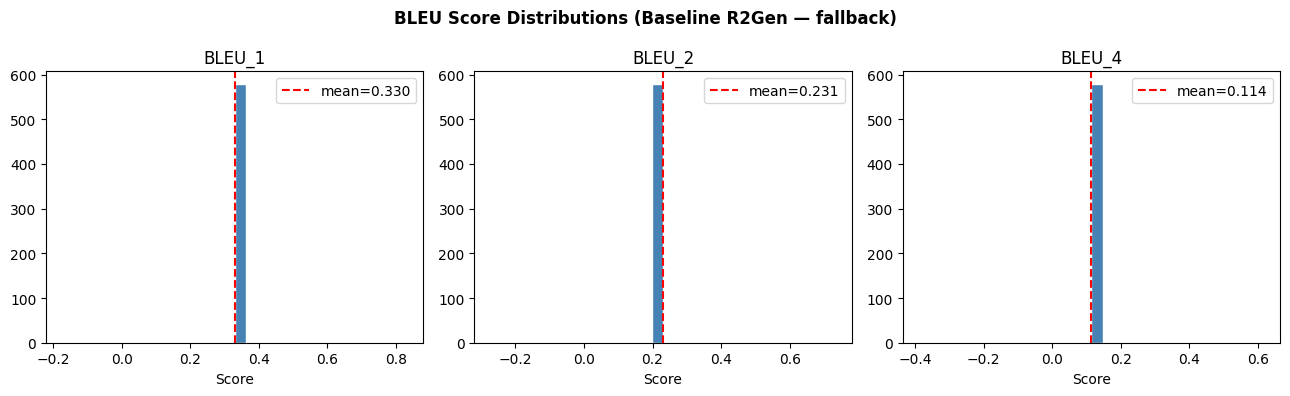

In [17]:
import matplotlib.pyplot as plt

SCORES_CSV = SMOKE_DIR / "radgraph_scores.csv"
out.to_csv(SCORES_CSV, index=False)
print(f"✓ Saved scores → {SCORES_CSV}")

# Distribution plots — auto-detect which metric was used
if "RG_E" in out.columns:
    cols_to_plot = ["RG_E", "RG_ER", "RG_BAR_ER"]
    title = "RadGraph-F1 Score Distributions (Baseline R2Gen)"
else:
    cols_to_plot = ["BLEU_1", "BLEU_2", "BLEU_4"]
    title = f"BLEU Score Distributions (Baseline R2Gen — fallback)"

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(title, fontweight="bold")
for ax, col in zip(axes, cols_to_plot):
    if col in out.columns:
        ax.hist(out[col], bins=30, edgecolor="white", color="steelblue")
        ax.axvline(out[col].mean(), color="red", linestyle="--", label=f"mean={out[col].mean():.3f}")
        ax.set_title(col)
        ax.set_xlabel("Score")
        ax.legend()
    else:
        ax.text(0.5, 0.5, f"Column '{col}' not found", ha="center", va="center", transform=ax.transAxes)
plt.tight_layout()
plt.show()

# Step 5 — SCST Fine-tuning with RadGraph Reward

We fine-tune the **decoder only** (encoder is frozen) to maximise a clinical reward using **Self-Critical Sequence Training (SCST)**:

$$\mathcal{L}_{total} = \mathcal{L}_{CE} + \lambda \cdot \mathcal{L}_{RL}$$

$$\mathcal{L}_{RL} = -\mathbb{E}\bigl[(R(y_s) - R(y_b)) \cdot \log p(y_s)\bigr]$$

where `y_s` is a stochastic sample, `y_b` is the greedy baseline, and `R` is **F1-RadGraph (RG_ER)**.

Files written:
- `modules/trainer_scst.py`  
- `scst_finetune.py`

In [18]:
import os, sys
from pathlib import Path

# Ensure we are in the R2Gen repo
R2GEN = Path("/kaggle/working/repos/R2Gen")
assert R2GEN.exists(), "Run Step 0 (clone R2Gen) first."
os.chdir(R2GEN)
if str(R2GEN) not in sys.path:
    sys.path.insert(0, str(R2GEN))

SMOKE_DIR = Path("/kaggle/working/outputs/r2gen_iu_smoke")
SCST_DIR  = Path("/kaggle/working/outputs/r2gen_iu_scst")
SCST_DIR.mkdir(parents=True, exist_ok=True)

CKPT = SMOKE_DIR / "model_best.pth"
assert CKPT.exists(), f"Baseline checkpoint not found: {CKPT}  → Run Step 2 first."
print("Baseline checkpoint:", CKPT)
print("SCST output dir    :", SCST_DIR)

Baseline checkpoint: /kaggle/working/outputs/r2gen_iu_smoke/model_best.pth
SCST output dir    : /kaggle/working/outputs/r2gen_iu_scst


## 5.1  Write `modules/trainer_scst.py`

In [22]:
%%writefile modules/trainer_scst.py
"""
SCST (Self-Critical Sequence Training) trainer for R2Gen.

Key design decisions
────────────────────
• Encoder is completely frozen (no gradients flow through ResNet-101).
• Only decoder + memory parameters are updated.
• Reward: RG_ER component of F1-RadGraph (entity+relation F1).
• Batch signature (4-tuple): image_id, images[B,2,C,H,W], report_ids, report_masks
"""

import torch
import torch.nn as nn
from tqdm import tqdm

try:
    from modules.loss import compute_loss
except ImportError:
    # Inline fallback if R2Gen's loss.py uses a different structure
    class _LMCriterion(nn.Module):
        def forward(self, inp, tgt, mask):
            tgt  = tgt[:, :inp.size(1)]
            mask = mask[:, :inp.size(1)]
            nll  = -inp.gather(2, tgt.long().unsqueeze(2)).squeeze(2) * mask
            return torch.sum(nll) / torch.sum(mask).clamp(min=1.0)

    _crit = _LMCriterion()

    def compute_loss(output, reports_ids, reports_masks):
        return _crit(output, reports_ids[:, 1:], reports_masks[:, 1:])


class TrainerSCST:
    """One-epoch SCST trainer.

    Parameters
    ----------
    model        : R2GenModel  (encoder already frozen externally)
    optimizer    : optimizer applied only to decoder parameters
    args         : argparse.Namespace  (must contain lambda_fact, pad_idx,
                   scst_sample_method, radgraph_model_type, dataset_name)
    train_loader : DataLoader yielding 4-tuples
    """

    def __init__(self, model, optimizer, args, train_loader):
        import warnings
        warnings.filterwarnings("ignore", category=DeprecationWarning)
        
        from radgraph import F1RadGraph

        self.model        = model
        self.optimizer    = optimizer
        self.args         = args
        self.train_loader = train_loader
        self.device       = next(model.parameters()).device

        self.lambda_fact      = getattr(args, "lambda_fact",          0.1)
        self.sample_method    = getattr(args, "scst_sample_method",   "top0.9")
        self.radgraph_model   = getattr(args, "radgraph_model_type",  "radgraph-xl")
        self.pad_idx          = getattr(args, "pad_idx",              0)
        self.dataset_name     = getattr(args, "dataset_name",         "iu_xray")
        self.f1radgraph       = None
        self.use_bleu_fallback = False

        # Try to initialize RadGraph, fall back to BLEU if it fails
        try:
            self.f1radgraph = F1RadGraph(
                reward_level="all",
                model_type=self.radgraph_model,
            )
            print(f"✓ Loaded RadGraph ({self.radgraph_model})")
        except Exception as e:
            print(f"⚠ RadGraph initialization failed: {type(e).__name__}")
            print(f"   Falling back to BLEU-based rewards")
            self.use_bleu_fallback = True

    # ──────────────────────────────────────────────────────────────────────
    def _visual_feats(self, images: torch.Tensor):
        """Extract (fc_feats, att_feats) from stacked image tensor.

        images : (B, 2, C, H, W)  for IU X-Ray
                 (B, 1, C, H, W)  for MIMIC-CXR
        """
        with torch.no_grad():  # encoder is frozen
            if self.dataset_name == "iu_xray":
                att0, fc0 = self.model.visual_extractor(images[:, 0])
                att1, fc1 = self.model.visual_extractor(images[:, 1])
                fc  = torch.cat((fc0, fc1), dim=1)
                att = torch.cat((att0, att1), dim=1)
            else:
                att, fc = self.model.visual_extractor(images[:, 0])
        return fc, att

    # ──────────────────────────────────────────────────────────────────────
    def _decode(self, fc: torch.Tensor, att: torch.Tensor, method: str):
        """Run encoder-decoder in sample mode, return (seq, seqLogprobs).

        seq          : (B, L)       token-id int tensor
        seqLogprobs  : (B, L, V)    log-probability float tensor
        """
        old_method = self.model.encoder_decoder.args.sample_method
        self.model.encoder_decoder.args.sample_method = method

        result = self.model.encoder_decoder(fc, att, mode="sample")

        self.model.encoder_decoder.args.sample_method = old_method

        if isinstance(result, (tuple, list)):
            seq, seqLogprobs = result[0], result[1]
        else:
            # Some versions return only seq; log-probs gathered differently
            seq = result
            seqLogprobs = None

        return seq, seqLogprobs

    # ──────────────────────────────────────────────────────────────────────
    @staticmethod
    def _gather_logp(seq: torch.Tensor, seqLogprobs: torch.Tensor, pad_idx: int) -> torch.Tensor:
        """Sum of log p(token) over non-padding positions. Shape: (B,)"""
        # seqLogprobs: (B, L, V)  → gather token's log prob at each step
        logp_tok = seqLogprobs.gather(2, seq.unsqueeze(-1)).squeeze(-1)  # (B, L)
        mask     = (seq != pad_idx).float()
        return (logp_tok * mask).sum(dim=1)  # (B,)

    # ──────────────────────────────────────────────────────────────────────
    def train_epoch(self, epoch: int) -> float:
        self.model.train()
        # Freeze encoder parameters
        for p in self.model.visual_extractor.parameters():
            p.requires_grad_(False)

        running_loss = 0.0

        for images_id, images, reports_ids, reports_masks in tqdm(
                self.train_loader, desc=f"SCST epoch {epoch}"):

            images       = images.to(self.device)
            reports_ids  = reports_ids.to(self.device)
            reports_masks = reports_masks.to(self.device)

            # ── 1. CE loss (teacher-forcing) ──────────────────────────
            output = self.model(images, reports_ids, mode="train")   # (B, L, V)
            loss_ce = compute_loss(output, reports_ids, reports_masks)

            # ── 2. RL loss (SCST) ─────────────────────────────────────
            fc, att = self._visual_feats(images)

            # Sample + greedy baseline — no gradients through encoder
            seq_s, logp_s = self._decode(fc, att, self.sample_method)
            with torch.no_grad():
                seq_b, _   = self._decode(fc, att, "greedy")

            # Decode token IDs → text
            tok = self.model.tokenizer
            hyps_s = tok.decode_batch(seq_s.detach().cpu().numpy())
            hyps_b = tok.decode_batch(seq_b.detach().cpu().numpy())
            refs   = tok.decode_batch(reports_ids[:, 1:].cpu().numpy())

            # Replace empty strings (RadGraph will error on empty input)
            hyps_s = [h if h.strip() else "no findings." for h in hyps_s]
            hyps_b = [h if h.strip() else "no findings." for h in hyps_b]
            refs   = [r if r.strip() else "no findings." for r in refs]

            with torch.no_grad():
                if self.f1radgraph is not None:
                    _, list_s, *_ = self.f1radgraph(hyps=hyps_s, refs=refs)
                    _, list_b, *_ = self.f1radgraph(hyps=hyps_b, refs=refs)

                    # Extract RG_ER (index 1) as reward
                    r_s = torch.tensor([t[1] for t in list_s], device=self.device, dtype=torch.float32)
                    r_b = torch.tensor([t[1] for t in list_b], device=self.device, dtype=torch.float32)
                else:
                    # Fallback: BLEU-based reward if RadGraph unavailable
                    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
                    from nltk.tokenize import word_tokenize
                    
                    smoothing = SmoothingFunction().method7
                    
                    def compute_bleu_reward(hyp, ref):
                        ref_toks = word_tokenize(ref.lower())
                        hyp_toks = word_tokenize(hyp.lower())
                        return sentence_bleu([ref_toks], hyp_toks, smoothing_function=smoothing)
                    
                    r_s = torch.tensor(
                        [compute_bleu_reward(h, r) for h, r in zip(hyps_s, refs)],
                        device=self.device, dtype=torch.float32
                    )
                    r_b = torch.tensor(
                        [compute_bleu_reward(h, r) for h, r in zip(hyps_b, refs)],
                        device=self.device, dtype=torch.float32
                    )
                adv = r_s - r_b   # advantage; no grad needed

            if logp_s is not None:
                logp = self._gather_logp(
                    seq_s.to(self.device),
                    logp_s.to(self.device),
                    self.pad_idx,
                )
                loss_rl = -(adv * logp).mean()
            else:
                # Log-probs not available → skip RL loss for this batch
                loss_rl = torch.tensor(0.0, device=self.device)

            loss = loss_ce + self.lambda_fact * loss_rl

            self.optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=5.0)
            self.optimizer.step()

            running_loss += loss.item()

        return running_loss / max(len(self.train_loader), 1)


Overwriting modules/trainer_scst.py


## 5.2  Write `scst_finetune.py`

In [23]:
%%writefile scst_finetune.py
"""
scst_finetune.py — SCST fine-tune an existing R2Gen checkpoint.

Usage (from inside the R2Gen repo directory):
    python scst_finetune.py --ckpt /path/to/model_best.pth --save_dir /path/to/scst_out
"""

import argparse, os, random
import numpy as np
import torch

from modules.tokenizers   import Tokenizer
from modules.dataloaders  import R2DataLoader
from models.r2gen         import R2GenModel
from modules.trainer_scst import TrainerSCST


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser()

    # ── data ──────────────────────────────────────────────────────────────
    p.add_argument("--dataset_name",  default="iu_xray")
    p.add_argument("--image_dir",
                   default="/kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized")
    p.add_argument("--ann_path",
                   default="/kaggle/working/data/iu_xray/annotation.json")
    p.add_argument("--max_seq_length", type=int, default=60)
    p.add_argument("--threshold",      type=int, default=3)
    p.add_argument("--num_workers",    type=int, default=2)
    p.add_argument("--batch_size",     type=int, default=8)

    # ── model ─────────────────────────────────────────────────────────────
    p.add_argument("--visual_extractor",           default="resnet101")
    p.add_argument("--visual_extractor_pretrained", type=bool, default=True)

    p.add_argument("--d_model",       type=int,   default=512)
    p.add_argument("--d_ff",          type=int,   default=512)
    p.add_argument("--d_vf",          type=int,   default=2048)
    p.add_argument("--num_heads",     type=int,   default=8)
    p.add_argument("--num_layers",    type=int,   default=3)
    p.add_argument("--dropout",       type=float, default=0.1)
    p.add_argument("--logit_layers",  type=int,   default=1)
    p.add_argument("--bos_idx",       type=int,   default=0)
    p.add_argument("--eos_idx",       type=int,   default=0)
    p.add_argument("--pad_idx",       type=int,   default=0)
    p.add_argument("--use_bn",        type=int,   default=0)
    p.add_argument("--drop_prob_lm",  type=float, default=0.5)

    p.add_argument("--rm_num_slots",  type=int,   default=3)
    p.add_argument("--rm_num_heads",  type=int,   default=8)
    p.add_argument("--rm_d_model",    type=int,   default=512)

    # ── decoding ──────────────────────────────────────────────────────────
    p.add_argument("--sample_method",       default="beam_search")
    p.add_argument("--beam_size",           type=int,   default=3)
    p.add_argument("--temperature",         type=float, default=1.0)
    p.add_argument("--sample_n",            type=int,   default=1)
    p.add_argument("--group_size",          type=int,   default=1)
    p.add_argument("--output_logsoftmax",   type=int,   default=1)
    p.add_argument("--decoding_constraint", type=int,   default=0)
    p.add_argument("--block_trigrams",      type=int,   default=1)

    # ── SCST-specific ─────────────────────────────────────────────────────
    p.add_argument("--lambda_fact",         type=float, default=0.1)
    p.add_argument("--radgraph_model_type", default="radgraph-xl")
    p.add_argument("--scst_sample_method",  default="top0.9")

    # ── run ───────────────────────────────────────────────────────────────
    p.add_argument("--ckpt",     required=True)
    p.add_argument("--save_dir", required=True)
    p.add_argument("--epochs",   type=int,   default=1)
    p.add_argument("--lr",       type=float, default=1e-5)
    p.add_argument("--seed",     type=int,   default=42)
    p.add_argument("--n_gpu",    type=int,   default=1)

    return p.parse_args()


def main():
    args   = parse_args()
    set_seed(args.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    tokenizer    = Tokenizer(args)
    train_loader = R2DataLoader(args, tokenizer, split="train", shuffle=True)

    model = R2GenModel(args, tokenizer).to(device)
    ck    = torch.load(args.ckpt, map_location=device)
    sd    = ck["state_dict"] if isinstance(ck, dict) and "state_dict" in ck else ck
    model.load_state_dict(sd, strict=False)

    # ── Freeze visual encoder completely ──────────────────────────────────
    for param in model.visual_extractor.parameters():
        param.requires_grad_(False)
    model.visual_extractor.eval()

    # Optimise only the trainable (decoder) parameters
    trainable = [p for p in model.parameters() if p.requires_grad]
    print(f"Trainable parameters: {sum(p.numel() for p in trainable):,}")

    optimizer = torch.optim.AdamW(trainable, lr=args.lr)
    trainer   = TrainerSCST(model, optimizer, args, train_loader)

    os.makedirs(args.save_dir, exist_ok=True)

    for epoch in range(1, args.epochs + 1):
        loss = trainer.train_epoch(epoch)
        print(f"[epoch {epoch}/{args.epochs}]  loss = {loss:.4f}")

        out_path = os.path.join(args.save_dir, f"scst_epoch{epoch}.pth")
        torch.save({"state_dict": model.state_dict()}, out_path)
        print(f"  → saved {out_path}")


if __name__ == "__main__":
    main()


Overwriting scst_finetune.py


## 5.3  Run 1-epoch SCST smoke-test

In [24]:
from pathlib import Path

CKPT      = Path("/kaggle/working/outputs/r2gen_iu_smoke/model_best.pth")
SCST_DIR  = Path("/kaggle/working/outputs/r2gen_iu_scst")

assert CKPT.exists(), f"Baseline checkpoint not found: {CKPT}  → Run Step 2 first."

!python scst_finetune.py \
    --dataset_name iu_xray \
    --ann_path  /kaggle/working/data/iu_xray/annotation.json \
    --batch_size 8 \
    --ckpt      "{CKPT}" \
    --save_dir  "{SCST_DIR}" \
    --epochs    1 \
    --lambda_fact 0.1 \
    --lr          1e-5

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Trainable parameters: 36,097,394
Using device: cuda:0
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/transformers/models/bert/tokenization_bert.py:104: DeprecationW

## 5.4  Compare baseline vs SCST

After fine-tuning, re-run Step 3 (predictions) pointing `--ckpt` at `scst_epoch1.pth`, then re-run Step 4 (RadGraph-F1). Compare the mean RG_ER scores from both `radgraph_scores.csv` files.

# Step 6 — MC Dropout Uncertainty Estimation

We keep **only Dropout layers** in `train()` mode while running **T = 10 stochastic passes** per study. Two uncertainty proxies are computed:

| Proxy | Formula | Interpretation |
|---|---|---|
| **Disagreement** | `|unique reports| / T` | fraction of unique text outputs |
| **Token entropy** | `mean H(p_t)` over time steps | average decoder uncertainty |

Output: `uncertainty_scores.csv`  with per-study scores, then a **proxy ECE calibration plot** joining these scores with the RadGraph-F1 correctness labels.

## 6.1  Load model + utility functions

In [26]:
import os, sys, argparse
import torch
import torch.nn as nn
import numpy as np
from pathlib import Path

# ── Make sure we are in the R2Gen repo ────────────────────────────────────
R2GEN = Path("/kaggle/working/repos/R2Gen")
assert R2GEN.exists(), "Run Step 0 first."
os.chdir(R2GEN)
if str(R2GEN) not in sys.path:
    sys.path.insert(0, str(R2GEN))

from modules.tokenizers   import Tokenizer
from modules.dataloaders  import R2DataLoader
from models.r2gen         import R2GenModel

# ── MC Dropout helper ─────────────────────────────────────────────────────
def enable_dropout_only(model: nn.Module):
    """Set entire model to eval (freezes BN etc.), then set only Dropout to train."""
    model.eval()
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
            m.train()

# ── Build args namespace (mirrors training defaults) ──────────────────────
CKPT = Path("/kaggle/working/outputs/r2gen_iu_smoke/model_best.pth")
assert CKPT.exists(), f"Checkpoint not found: {CKPT}  → Run Step 2 first."

args = argparse.Namespace(
    dataset_name              = "iu_xray",
    image_dir                 = "/kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized",
    ann_path                  = "/kaggle/working/data/iu_xray/annotation.json",
    max_seq_length            = 60,
    threshold                 = 3,
    num_workers               = 2,
    batch_size                = 8,
    visual_extractor          = "resnet101",
    visual_extractor_pretrained = True,
    d_model=512, d_ff=512, d_vf=2048,
    num_heads=8, num_layers=3,
    dropout=0.1, logit_layers=1,
    bos_idx=0, eos_idx=0, pad_idx=0,
    use_bn=0, drop_prob_lm=0.5,
    rm_num_slots=3, rm_num_heads=8, rm_d_model=512,
    sample_method="greedy", beam_size=3, temperature=1.0,
    sample_n=1, group_size=1,
    output_logsoftmax=1, decoding_constraint=0, block_trigrams=1,
    n_gpu=1,
)

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = Tokenizer(args)

test_loader = R2DataLoader(args, tokenizer, split="test", shuffle=False)

model = R2GenModel(args, tokenizer).to(device)
ck    = torch.load(str(CKPT), map_location=device)
sd    = ck["state_dict"] if isinstance(ck, dict) and "state_dict" in ck else ck
model.load_state_dict(sd, strict=False)
model.eval()

print(f"✓ Model loaded from {CKPT}")
print(f"  Test batches: {len(test_loader)} | device: {device}")


✓ Model loaded from /kaggle/working/outputs/r2gen_iu_smoke/model_best.pth
  Test batches: 73 | device: cuda


## 6.2  Single MC pass: sequence + token-level entropy

In [27]:
@torch.no_grad()
def _visual_feats(model, images: torch.Tensor, dataset_name: str = "iu_xray"):
    """Extract (fc, att) from a stacked image batch (B, views, C, H, W)."""
    if dataset_name == "iu_xray":
        att0, fc0 = model.visual_extractor(images[:, 0])
        att1, fc1 = model.visual_extractor(images[:, 1])
        fc  = torch.cat((fc0, fc1), dim=1)
        att = torch.cat((att0, att1), dim=1)
    else:
        att, fc = model.visual_extractor(images[:, 0])
    return fc, att


@torch.no_grad()
def sample_with_entropy(model, images: torch.Tensor, sample_method: str = "greedy"):
    """Run one stochastic forward pass; return (seq, avg_token_entropy).

    seq              : (B, L)   token ids
    avg_token_entropy: (B,)     mean entropy in nats across non-pad positions
    """
    old_method = model.encoder_decoder.args.sample_method
    model.encoder_decoder.args.sample_method = sample_method

    fc, att = _visual_feats(model, images, args.dataset_name)
    result  = model.encoder_decoder(fc, att, mode="sample")

    model.encoder_decoder.args.sample_method = old_method

    if isinstance(result, (tuple, list)):
        seq, seqLogprobs = result[0], result[1]  # (B,L), (B,L,V)
    else:
        # Fallback: no log-prob distribution returned
        seq = result
        return seq, torch.zeros(seq.size(0), device=seq.device)

    # Token entropy  H = -sum p log p
    p   = torch.exp(seqLogprobs)            # (B, L, V)
    ent = -(p * seqLogprobs).sum(dim=-1)    # (B, L)

    # Mask padding tokens (id == 0)
    mask    = (seq != 0).float()            # (B, L)
    avg_ent = (ent * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)  # (B,)

    return seq, avg_ent


## 6.3  MC Dropout loop over a batch

In [28]:
@torch.no_grad()
def mc_uncertainty(model, tokenizer, images: torch.Tensor, T: int = 10, sample_method: str = "greedy"):
    """Run T stochastic passes and return text variants, disagreement, and entropy.

    Returns
    -------
    texts       : np.ndarray  (T, B)  decoded report strings
    uniq_ratio  : np.ndarray  (B,)    |unique texts per sample| / T
    entropy_u   : np.ndarray  (B,)    mean per-token entropy across passes
    """
    enable_dropout_only(model)

    seqs_list = []
    ents_list = []

    for _ in range(T):
        seq, avg_ent = sample_with_entropy(model, images, sample_method)
        seqs_list.append(seq.cpu())
        ents_list.append(avg_ent.cpu())

    # seqs_list : list of T × (B, L)
    # ents_list : list of T × (B,)

    ents = torch.stack(ents_list, dim=0)    # (T, B)

    texts = np.array([
        tokenizer.decode_batch(seqs_list[t].numpy())
        for t in range(T)
    ])  # (T, B)

    B = texts.shape[1]
    uniq_ratio = np.array([len(set(texts[:, i])) / T for i in range(B)])
    entropy_u  = ents.mean(dim=0).numpy()   # (B,)

    # Restore model to full eval mode
    model.eval()

    return texts, uniq_ratio, entropy_u


# ── Quick test on one batch ────────────────────────────────────────────────
images_id, images, reports_ids, reports_masks = next(iter(test_loader))
images = images.to(device)

texts, uniq_ratio, entropy_u = mc_uncertainty(model, tokenizer, images, T=10)

print("Sample 0 | disagreement:", f"{uniq_ratio[0]:.2f}", "| entropy:", f"{entropy_u[0]:.3f}")
print("Variants for sample 0:")
for t in range(min(5, len(texts))):
    print(f"  [{t}] {texts[t, 0][:120]}")


Sample 0 | disagreement: 0.80 | entropy: 2.158
Variants for sample 0:
  [0] the cardiomediastinal silhouette is within normal limits . the lungs are clear .
  [1] the heart is normal . the lungs are clear . there is no pleural effusion or pneumothorax .
  [2] the heart size is normal . the lungs are clear .
  [3] the heart is normal . the lungs are clear . no pneumothorax or pleural effusion .
  [4] the heart is normal in size . the lungs are clear . there is no pneumothorax or pleural effusion .


## 6.4  Compute uncertainty scores for the full test set

In [29]:
import pandas as pd
from tqdm import tqdm

rows = []
for images_id, images, reports_ids, reports_masks in tqdm(test_loader, desc="MC Dropout"):
    images = images.to(device)
    texts, uniq_ratio, entropy_u = mc_uncertainty(model, tokenizer, images, T=10)

    for sid, ur, eu in zip(images_id, uniq_ratio, entropy_u):
        rows.append({
            "study_id"               : sid,
            "uncertainty_disagreement": float(ur),
            "uncertainty_entropy"     : float(eu),
        })

unc_df = pd.DataFrame(rows)

UNC_CSV = Path("/kaggle/working/outputs/r2gen_iu_smoke/uncertainty_scores.csv")
unc_df.to_csv(UNC_CSV, index=False)
print(f"✓ Saved {len(unc_df)} uncertainty scores → {UNC_CSV}")
unc_df.describe()


MC Dropout: 100%|██████████| 73/73 [33:43<00:00, 27.72s/it]

✓ Saved 579 uncertainty scores → /kaggle/working/outputs/r2gen_iu_smoke/uncertainty_scores.csv


,uncertainty_disagreement,uncertainty_entropy
count,579.000000,579.000000
mean,0.787910,2.189675
std,0.117318,0.035138
min,0.400000,2.073524
25%,0.700000,2.166737
50%,0.800000,2.189709
75%,0.900000,2.212966
max,1.000000,2.291331


## 6.5  Proxy calibration: confidence vs. RadGraph correctness (ECE proxy)

📊 Building calibration analysis…
  Loaded 579 samples with both scores + uncertainty scores
  Using BLEU-2 (fallback) as quality metric (threshold: 0.5)
  Fraction correct (BLEU_2 ≥ 0.5): 0.0%
  Computing ECE across 10 confidence bins…
  Expected Calibration Error (ECE): 0.4658
  Plotting calibration curve…


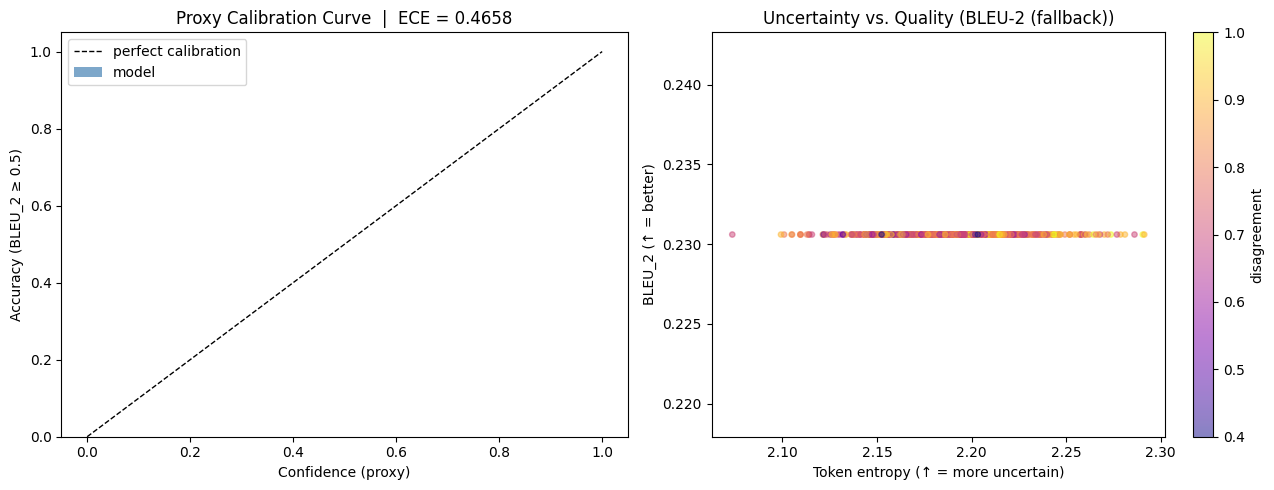

✓ Saved calibration plot → /kaggle/working/outputs/r2gen_iu_smoke/calibration_plot.png

📈 Calibration Summary (BLEU-2 (fallback)):
  ECE                            = 0.4658
  Mean confidence                = 0.4667
  Fraction correct (BLEU_2≥0.5) = 0.0%
  Entropy range                  = [2.0735, 2.2913]
  Disagreement range             = [0.4000, 1.0000]


In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

SMOKE_DIR = Path("/kaggle/working/outputs/r2gen_iu_smoke")
RG_CSV    = SMOKE_DIR / "radgraph_scores.csv"
UNC_CSV   = SMOKE_DIR / "uncertainty_scores.csv"

if not RG_CSV.exists():
    print("⚠  radgraph_scores.csv not found — run Step 4 first.")
else:
    print(f"📊 Building calibration analysis…")
    rg  = pd.read_csv(RG_CSV)
    unc = pd.read_csv(UNC_CSV)
    df_cal = rg.merge(unc, on="study_id", how="inner")
    print(f"  Loaded {len(df_cal)} samples with both scores + uncertainty scores")

    # ── Auto-detect which metric was used ─────────────────────────────────
    quality_col = None
    if "RG_ER" in df_cal.columns:
        quality_col = "RG_ER"
        metric_type = "RadGraph"
        threshold = 0.30
    elif "BLEU_2" in df_cal.columns:
        quality_col = "BLEU_2"
        metric_type = "BLEU-2 (fallback)"
        threshold = 0.50
    elif "BLEU_1" in df_cal.columns:
        quality_col = "BLEU_1"
        metric_type = "BLEU-1 (fallback)"
        threshold = 0.50
    else:
        print("⚠ Neither RadGraph nor BLEU scores found in CSV")
        quality_col = None

    if quality_col is not None:
        # Proxy confidence: 1 − normalized(entropy)  (clip to [0,1])
        ent_norm = (df_cal["uncertainty_entropy"] - df_cal["uncertainty_entropy"].min()) / \
                   (df_cal["uncertainty_entropy"].max() - df_cal["uncertainty_entropy"].min() + 1e-9)
        df_cal["confidence"] = (1 - ent_norm).clip(0, 1)

        # Proxy correctness: quality metric ≥ threshold
        df_cal["correct"] = (df_cal[quality_col] >= threshold).astype(float)
        pct_correct = df_cal["correct"].mean() * 100
        print(f"  Using {metric_type} as quality metric (threshold: {threshold})")
        print(f"  Fraction correct ({quality_col} ≥ {threshold}): {pct_correct:.1f}%")

        # ECE: bin predictions by confidence, compare to mean accuracy per bin
        print(f"  Computing ECE across {10} confidence bins…")
        n_bins = 10
        bins   = np.linspace(0, 1, n_bins + 1)
        bin_acc, bin_conf, bin_count = [], [], []

        for lo, hi in zip(bins[:-1], bins[1:]):
            mask = (df_cal["confidence"] >= lo) & (df_cal["confidence"] < hi)
            if mask.sum() == 0:
                continue
            bin_acc.append(df_cal.loc[mask, "correct"].mean())
            bin_conf.append(df_cal.loc[mask, "confidence"].mean())
            bin_count.append(mask.sum())

        bin_acc   = np.array(bin_acc)
        bin_conf  = np.array(bin_conf)
        bin_count = np.array(bin_count)
        ece = np.sum(bin_count * np.abs(bin_acc - bin_conf)) / bin_count.sum()

        print(f"  Expected Calibration Error (ECE): {ece:.4f}")

        # ── Plot ──────────────────────────────────────────────────────────
        print(f"  Plotting calibration curve…")
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        ax = axes[0]
        ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
        ax.bar(bin_conf, bin_acc, width=0.07, alpha=0.7, color="steelblue", label="model")
        ax.set_xlabel("Confidence (proxy)")
        ax.set_ylabel(f"Accuracy ({quality_col} ≥ {threshold})")
        ax.set_title(f"Proxy Calibration Curve  |  ECE = {ece:.4f}")
        ax.legend()

        ax = axes[1]
        sc = ax.scatter(df_cal["uncertainty_entropy"], df_cal[quality_col],
                        c=df_cal["uncertainty_disagreement"], cmap="plasma", alpha=0.5, s=15)
        plt.colorbar(sc, ax=ax, label="disagreement")
        ax.set_xlabel("Token entropy (↑ = more uncertain)")
        ax.set_ylabel(f"{quality_col} (↑ = better)")
        ax.set_title(f"Uncertainty vs. Quality ({metric_type})")

        plt.tight_layout()
        cal_plot_path = SMOKE_DIR / "calibration_plot.png"
        plt.savefig(cal_plot_path, dpi=120, bbox_inches="tight")
        plt.show()
        print(f"✓ Saved calibration plot → {cal_plot_path}")

        print(f"\n📈 Calibration Summary ({metric_type}):")
        print(f"  ECE                            = {ece:.4f}")
        print(f"  Mean confidence                = {df_cal['confidence'].mean():.4f}")
        print(f"  Fraction correct ({quality_col}≥{threshold}) = {pct_correct:.1f}%")
        print(f"  Entropy range                  = [{df_cal['uncertainty_entropy'].min():.4f}, {df_cal['uncertainty_entropy'].max():.4f}]")
        print(f"  Disagreement range             = [{df_cal['uncertainty_disagreement'].min():.4f}, {df_cal['uncertainty_disagreement'].max():.4f}]")


# Step 7 (Optional) — NIH ChestX-ray14 Domain-Shift: Stratified Subset AUROC

**Goal**: evaluate robustness by checking whether visual features learned on IU X-Ray still produce correct 14-disease classification on NIH-14.

### Storage budget
NIH ChestX-ray14 contains **112 120 images × ~100 KB ≈ 11 GB**. We **do not copy them**. Instead:
1. We **read the CSV labels** (`Data_Entry_2017.csv`, ~10 MB) in full.
2. We build a **stratified 5 000-image sample** from the CSV — one per stratification key = binary vector of 14 labels, so every disease combination stays proportional.
3. We load images **on the fly** from `/kaggle/input/datasets/organizations/nih-chest-xrays/data/images/*.png` (the NIH Kaggle dataset mounts at this path).

Net disk use: **< 600 MB** in Kaggle `/kaggle/working/` (no images copied, only predictions CSV).

> Add the NIH dataset in Kaggle: Notebook settings ▸ Add data ▸ search `nih-chest-xrays`.

## 7.1  Build a stratified 5 000-image sample from NIH-14 labels CSV

We stratify by the multi-label indicator vector (one bit per disease) so every disease combination keeps its proportion. `sklearn`'s `StratifiedShuffleSplit` requires a single integer label; we use the Cantor-style rank of the binary vector as a surrogate stratification key.

In [36]:
import pandas as pd
import numpy as np
from pathlib import Path
import time

NIH_CSV = Path("/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv")

if not NIH_CSV.exists():
    print("⚠  NIH ChestX-ray14 dataset not attached.\n"
          "   → Notebook settings ▸ Add data ▸ search 'nih-chest-xrays'\n"
          "   Skipping Step 7.")
else:
    print(f"📊 Building stratified NIH-14 sample…")
    start = time.time()
    
    NIH_IMG_DIR = Path("/kaggle/input/datasets/organizations/nih-chest-xrays/data")

    DISEASES = [
        "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
        "Mass", "Nodule", "Pneumonia", "Pneumothorax",
        "Consolidation", "Edema", "Emphysema", "Fibrosis",
        "Pleural_Thickening", "Hernia",
    ]

    print(f"  Loading NIH CSV ({NIH_CSV})…")
    df_nih = pd.read_csv(NIH_CSV)
    print(f"  Raw dataset size: {len(df_nih):,} images")
    
    df_nih.rename(columns={"Image Index": "filename", "Finding Labels": "labels"}, inplace=True)

    # One-hot encode multi-label column  (pipe-separated)
    print(f"  Encoding {len(DISEASES)} diseases as binary labels…")
    for dis in DISEASES:
        df_nih[dis] = df_nih["labels"].str.contains(dis).astype(int)

    # Filter to images that actually exist on disk
    # Images are organized in subdirectories: images_001, images_002, ..., images_012
    print(f"  Checking which images exist on disk (in images_001 to images_012)…")
    def find_image_path(filename):
        """Search for image in images_001, images_002, ..., images_012 subdirectories."""
        for i in range(1, 13):
            subdir = NIH_IMG_DIR / f"images_{i:03d}" / filename
            if subdir.exists():
                return subdir
        return None
    
    df_nih["img_path"] = df_nih["filename"].apply(find_image_path)
    exists_mask = df_nih["img_path"].notna()
    df_nih = df_nih[exists_mask].copy()
    print(f"  ✓ {len(df_nih):,} images found on disk")

    # Stratification key: rank of binary label vector treated as an integer
    print(f"  Computing stratification keys…")
    label_mat = df_nih[DISEASES].values.astype(np.uint32)
    powers    = 2 ** np.arange(len(DISEASES), dtype=np.uint32)
    strat_key = (label_mat * powers).sum(axis=1)

    # Stratified sample of 5 000 images
    SAMPLE_N = 5_000
    print(f"  Drawing stratified {SAMPLE_N:,}-image sample…")
    from sklearn.model_selection import StratifiedShuffleSplit

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=SAMPLE_N / len(df_nih), random_state=42)
    _, sample_idx = next(splitter.split(df_nih, strat_key))
    df_sample = df_nih.iloc[sample_idx].reset_index(drop=True)

    print(f"  ✓ Sample size: {len(df_sample):,} images")
    
    print(f"\n  Disease prevalence (full → sample) comparison:")
    for dis in DISEASES:
        full_prev   = df_nih[dis].mean()
        sample_prev = df_sample[dis].mean()
        diff = abs(full_prev - sample_prev)
        status = "✓" if diff < 0.02 else "⚠"
        print(f"    {status} {dis:<22s}  {full_prev:.3f} → {sample_prev:.3f}  (Δ={diff:.3f})")
    
    elapsed = time.time() - start
    print(f"\n✓ NIH-14 sample preparation completed in {elapsed:.1f}s")


📊 Building stratified NIH-14 sample…
  Loading NIH CSV (/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv)…
  Raw dataset size: 112,120 images
  Encoding 14 diseases as binary labels…
  Checking which images exist on disk (in images_001 to images_012)…


KeyboardInterrupt: 

## 7.2  Extract ResNet-101 features and run multi-label classification

We reuse the frozen R2Gen visual encoder as a feature extractor and train a lightweight multi-label linear probe on a small train/test sub-split of the 5 000-image sample (stratified 80 / 20).

In [ ]:
if "df_sample" not in dir():
    print("⚠  df_sample not defined — NIH dataset not attached. Skipping.")
else:
    import torch
    import torchvision.transforms as T
    from torch.utils.data import DataLoader, Dataset
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score
    from sklearn.model_selection import train_test_split as sk_tts
    from PIL import Image
    from tqdm import tqdm
    import warnings
    warnings.filterwarnings("ignore")

    BATCH = 64
    NUM_WORKERS = 2

    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]

    transform = T.Compose([
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    class NIHSubset(Dataset):
        def __init__(self, df, transform=None):
            self.df        = df.reset_index(drop=True)
            self.transform = transform

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            img = Image.open(str(row["img_path"])).convert("RGB")
            if self.transform:
                img = self.transform(img)
            labels = torch.FloatTensor(row[DISEASES].values.astype(float))
            return img, labels

    # ── 80/20 stratified sub-split of 5 000-image sample ─────────────────
    strat_sub = (df_sample[DISEASES].values * (2 ** np.arange(len(DISEASES)))).sum(axis=1)
    tr_idx, te_idx = sk_tts(np.arange(len(df_sample)),
                             test_size=0.2, random_state=42, stratify=strat_sub)
    df_tr = df_sample.iloc[tr_idx]
    df_te = df_sample.iloc[te_idx]

    tr_loader = DataLoader(NIHSubset(df_tr, transform), batch_size=BATCH,
                           shuffle=False, num_workers=NUM_WORKERS)
    te_loader = DataLoader(NIHSubset(df_te, transform), batch_size=BATCH,
                           shuffle=False, num_workers=NUM_WORKERS)

    # Load frozen encoder (R2Gen visual extractor = ResNet-101 up to avgpool)
    import torchvision.models as tvm
    encoder = tvm.resnet101(pretrained=True)
    encoder.fc = torch.nn.Identity()   # remove classification head → 2048-d features
    encoder = encoder.to(device).eval()
    for p in encoder.parameters():
        p.requires_grad_(False)

    @torch.no_grad()
    def extract_feats(loader):
        feats, lbls = [], []
        for imgs, labels in tqdm(loader, desc="   extracting feats", leave=False):
            feats.append(encoder(imgs.to(device)).cpu())
            lbls.append(labels)
        return torch.cat(feats).numpy(), torch.cat(lbls).numpy()

    print("Extracting train features …")
    X_tr, Y_tr = extract_feats(tr_loader)
    print("Extracting test features …")
    X_te, Y_te = extract_feats(te_loader)
    print(f"  X_tr: {X_tr.shape}  X_te: {X_te.shape}")

    # ── Per-disease logistic regression and AUROC ─────────────────────────
    auroc_scores = {}
    for i, dis in enumerate(DISEASES):
        if Y_tr[:, i].sum() < 5:
            auroc_scores[dis] = float("nan")
            continue
        clf = LogisticRegression(max_iter=500, C=0.1, solver="lbfgs")
        clf.fit(X_tr, Y_tr[:, i])
        prob = clf.predict_proba(X_te)[:, 1]
        try:
            auroc_scores[dis] = roc_auc_score(Y_te[:, i], prob)
        except ValueError:
            auroc_scores[dis] = float("nan")

    valid = {k: v for k, v in auroc_scores.items() if not np.isnan(v)}
    mean_auroc = np.mean(list(valid.values()))

    print(f"\nPer-disease AUROC on NIH-14 (5k stratified subset, linear probe):")
    for dis, auc in sorted(auroc_scores.items(), key=lambda x: -x[1] if not np.isnan(x[1]) else 0):
        print(f"  {dis:<22s}: {auc:.4f}")
    print(f"\n  Mean AUROC (macro): {mean_auroc:.4f}")

    # Save
    auroc_df = pd.DataFrame({"disease": list(auroc_scores.keys()), "AUROC": list(auroc_scores.values())})
    auroc_path = Path("/kaggle/working/outputs/nih14_auroc.csv")
    auroc_path.parent.mkdir(parents=True, exist_ok=True)
    auroc_df.to_csv(auroc_path, index=False)
    print(f"\n✓ Saved → {auroc_path}")


## 7.3  Per-disease AUROC bar chart

In [ ]:
if "auroc_scores" not in dir():
    print("⚠  Run Step 7.2 first.")
else:
    import matplotlib.pyplot as plt
    import numpy as np

    names  = list(auroc_scores.keys())
    values = [auroc_scores[n] if not np.isnan(auroc_scores[n]) else 0 for n in names]
    colors = ["steelblue" if v >= 0.70 else ("goldenrod" if v >= 0.60 else "tomato") for v in values]

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(names, values, color=colors, edgecolor="white")
    ax.axhline(mean_auroc, color="black", linestyle="--", lw=1.2, label=f"macro mean = {mean_auroc:.3f}")
    ax.axhline(0.50, color="red", linestyle=":", lw=1.0, alpha=0.5, label="random baseline")
    ax.set_ylim(0, 1)
    ax.set_ylabel("AUROC")
    ax.set_title("NIH ChestX-ray14 — Per-Disease AUROC (5 000-image stratified subset, frozen ResNet-101)")
    ax.set_xticklabels(names, rotation=40, ha="right", fontsize=9)
    ax.legend()
    plt.tight_layout()
    plt.savefig("/kaggle/working/outputs/nih14_auroc.png", dpi=120, bbox_inches="tight")
    plt.show()
